# Explore current profiles

ADCP observations describe currents at multiple measurement bins. Learn how their extra dimension differs from an ordinary station time series, and plot current speed through time.

The first code cell records when this notebook was executed against NOAA services.


In [1]:
from datetime import datetime, timezone
print("NOAA execution started (UTC):", datetime.now(timezone.utc).isoformat())

import matplotlib.pyplot as plt
import xndbc

station_id = "41051"
year = 2013

## Select the current-profile product

`mode="adcp"` selects acoustic Doppler current profiles. Download an explicit station and archive year to inspect depth-dependent measurements.

In [2]:
xndbc.list_modes().sel(mode="adcp")

<xarray.Dataset> Size: 202B
Dimensions:      ()
Coordinates:
    mode         <U6 24B 'adcp'
Data variables:
    description  <U44 176B 'Acoustic Doppler current profiles'
    historical   bool 1B True
    realtime     bool 1B True

## Read the profile variables

`DEP` contains measurement depths, `DIR` current directions, and `SPD` current speeds. Select the single station to leave `time` and `depth_bin` dimensions. Observation dimensions are `station_id`, `time`, and `depth_bin`; timestamps are UTC. Select a bin or reduce explicitly before making an ordinary time series.

In [3]:
data = xndbc.historical(station_id, years=year, mode="adcp", progress=False)
currents = data.sel(station_id=station_id)
currents

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 5398, depth_bin: 29)
Coordinates:
  * time          (time) datetime64[us] 43kB 2013-03-07T18:00:00 ... 2013-12-...
  * depth_bin     (depth_bin) int64 232B 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
    station_id    <U5 20B '41051'
    latitude      float64 8B 18.26
    longitude     float64 8B -65.0
    name          <U76 304B 'South of St. Thomas, VI'
    owner         <U3 12B 'CI'
    station_type  <U40 160B 'Moored Buoy'
    notes         <U990 4kB ''
Data variables:
    DEP           (time, depth_bin) float64 1MB 1.5 2.5 3.5 ... 28.0 29.0 30.0
    DIR           (time, depth_bin) int64 1MB 337 330 338 339 ... 340 351 344
    SPD           (time, depth_bin) float64 1MB 16.2 27.5 23.4 ... 8.1 6.4 5.0
Attributes:
    source:        NOAA National Data Buoy Center
    feed:          historical
    ndbc_mode:     adcp
    retrieved_at:  2026-09-10T14:52:00.713770+00:00
    ndbc_report:   [{"station_id": "41051", "year": 2013, "url": "https://www...
    sampling:      Original observations; no temporal resampling

## Inspect actual depths

`depth_bin` is a bin number, not a physical depth coordinate. Inspect `DEP` at the timestamp of interest; depths may vary with time and some bins may be missing.

In [4]:
currents.DEP.isel(time=0)

<xarray.DataArray 'DEP' (depth_bin: 29)> Size: 232B
array([ 1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5, 11.5,
       12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5,
       23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5])
Coordinates:
  * depth_bin     (depth_bin) int64 232B 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
    station_id    <U5 20B '41051'
    time          datetime64[us] 8B 2013-03-07T18:00:00
    latitude      float64 8B 18.26
    longitude     float64 8B -65.0
    name          <U76 304B 'South of St. Thomas, VI'
    owner         <U3 12B 'CI'
    station_type  <U40 160B 'Moored Buoy'
    notes         <U990 4kB ''
Attributes:
    long_name:  Current measurement depth
    units:      m

## Plot speed across bins and time

Focus on the first 168 observations to make the changes easy to see. This selects records, not a guaranteed number of days. The vertical axis shows bin number, and the color scale shows current speed with units from the dataset. No averaging or depth interpolation is performed.

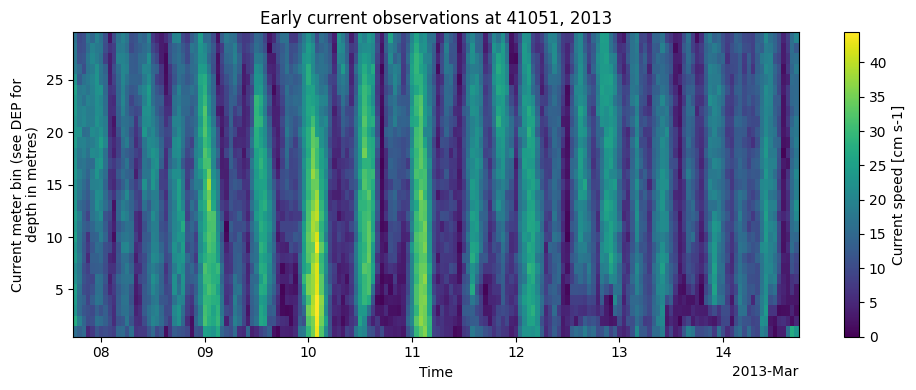

In [5]:
speed = currents.SPD.isel(time=slice(0, 168))
speed.plot.pcolormesh(x="time", y="depth_bin", figsize=(10, 4))
plt.title(f"Early current observations at {station_id}, {year}")
plt.tight_layout()
plt.show()

## Follow one bin

Use xarray to select a measurement bin for a time series. Current direction is an angle: an ordinary arithmetic mean can be misleading near 0/360 degrees, so this example plots speed only.

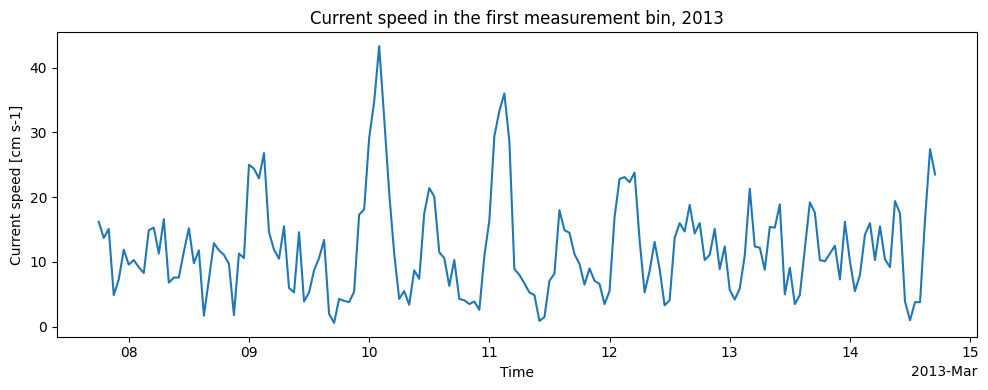

In [6]:
speed.isel(depth_bin=0).plot.line(x="time", figsize=(10, 4))
plt.title(f"Current speed in the first measurement bin, {year}")
plt.tight_layout()
plt.show()

For another product with an extra dimension, continue to [Wave Spectra](wave_spectra.ipynb).